# Concept-Copying Head Analysis

This notebook analyzes the top concept-copying heads on the traced improbable-bigram cache.

It focuses on:

- concept-head `LTM` as the attention-pattern diagnostic
- concept-head `DLA` to the correct second token and the predicted wrong token

The current cache supports:

- hallucinated improbable bigrams
- copied improbable bigrams
- random two-token phrase controls

It does **not** include the true two-token concept condition from the proposal, so the notebook can only provide a partial Hypothesis 2 readout.


In [1]:
import sys
from pathlib import Path

from IPython.display import Markdown, display


def find_repo_root(start: Path) -> Path:
    candidates = []
    for candidate in (start, *start.parents):
        candidates.extend(
            [
                candidate,
                candidate / "dual-route-induction",
                candidate / "improbable-bigram-causality" / "dual-route-induction",
            ]
        )

    for candidate in candidates:
        if (candidate / "cache").exists() and (candidate / "scripts").exists():
            return candidate.resolve()

    raise FileNotFoundError(
        "Could not locate the dual-route-induction repo root from the current working directory."
    )


ROOT = find_repo_root(Path.cwd().resolve())
if str(ROOT / "scripts") not in sys.path:
    sys.path.insert(0, str(ROOT / "scripts"))

import hypothesis1_utils as h1

h1.configure_matplotlib()
CACHE = h1.load_cache(ROOT)
DEFAULT_TOP_K = 32
ROOT

WindowsPath('D:/uni/courses/S2026/CS_7180/Project/improbable-bigram-causality/dual-route-induction')

## Coverage

The proposal's concept-head diagnostic compares three conditions:

1. hallucinated improbable bigrams
2. random two-token phrases
3. coherent two-token concepts

Only conditions 1 and 2 are present in the current cache. The notebook therefore uses copied improbable examples as an internal control, but it cannot fully distinguish the three-way Hypothesis 2 scenarios in the proposal.


In [2]:
display(Markdown(h1.trace_consistency_markdown(CACHE)))
display(h1.dataset_overview(CACHE))

### Trace Consistency
The prompt-summary JSON is not present in this repo snapshot. The notebook therefore uses the traced cache directly.

,dataset,examples,hallucinated_second_token,copied
0,Improbable summary,100,33,67
1,Updated trace cache,100,33,67
2,Random phrase cache,35,0,35


In [3]:
summary = h1.build_concept_pairwise_summary(CACHE, DEFAULT_TOP_K)
display(summary.round(6))
display(Markdown(h1.concept_interpretation_markdown(CACHE, DEFAULT_TOP_K)))

,metric,comparison,left_mean,right_mean,diff,ci_low,ci_high
0,Concept LTM (raw),Hallucinated - Copied,0.030744,0.030024,0.000720,-0.000875,0.002319
1,Concept LTM (raw),Hallucinated - Random,0.030744,0.020199,0.010545,0.008477,0.012554
2,Concept LTM (value-weighted),Hallucinated - Copied,0.065061,0.063129,0.001933,-0.000598,0.004469
3,Concept LTM (value-weighted),Hallucinated - Random,0.065061,0.044835,0.020227,0.016865,0.023425
4,Concept correct-token DLA,Hallucinated - Copied,0.012735,0.014334,-0.001599,-0.004009,0.000796
5,Concept correct-token DLA,Hallucinated - Random,0.012735,0.008833,0.003902,0.000475,0.007102
6,Hallucinated concept DLA,Wrong-token - Correct-token,0.005659,0.012735,-0.007076,-0.010125,-0.003935


### Concept-Head Readout at Top-32
- Hallucinated vs copied LTM: `0.0007` (95% CI `-0.0009` to `0.0023`)
- Hallucinated vs copied correct-token DLA: `-0.0016` (95% CI `-0.0040` to `0.0008`)
- Hallucinated vs random LTM: `0.0105` (95% CI `0.0085` to `0.0126`)
- Hallucinated vs random correct-token DLA: `0.0039` (95% CI `0.0005` to `0.0071`)
- Hallucinated wrong-token minus correct-token DLA: `-0.0071` (95% CI `-0.0101` to `-0.0039`)

The current cache only includes conditions (1) hallucinated improbable bigrams and (2) random two-token phrases, plus copied improbable prompts as an internal control. Because the true two-token concept condition is missing, this notebook cannot fully resolve the proposal's three-way Hypothesis 2 scenarios. In the current traced cache, concept heads look broadly similar on hallucinated and copied improbable prompts, and they do not strongly favor the wrong token over the correct token in hallucinated cases.

,metric,condition,k,mean,ci_low,ci_high
0,Concept LTM (raw),Hallucinated improbable,8,0.073226,0.068589,0.077656
1,Concept LTM (raw),Copied improbable,8,0.072072,0.068983,0.075185
2,Concept LTM (raw),Random phrases,8,0.040927,0.036216,0.045997
3,Concept LTM (raw),Hallucinated improbable,16,0.045304,0.042916,0.047652
4,Concept LTM (raw),Copied improbable,16,0.044039,0.042469,0.045561
5,Concept LTM (raw),Random phrases,16,0.025564,0.023055,0.028302
6,Concept LTM (raw),Hallucinated improbable,32,0.030744,0.029396,0.032061
7,Concept LTM (raw),Copied improbable,32,0.030024,0.029103,0.030925
8,Concept LTM (raw),Random phrases,32,0.020199,0.018701,0.021863
9,Concept LTM (raw),Hallucinated improbable,64,0.032650,0.031623,0.033669


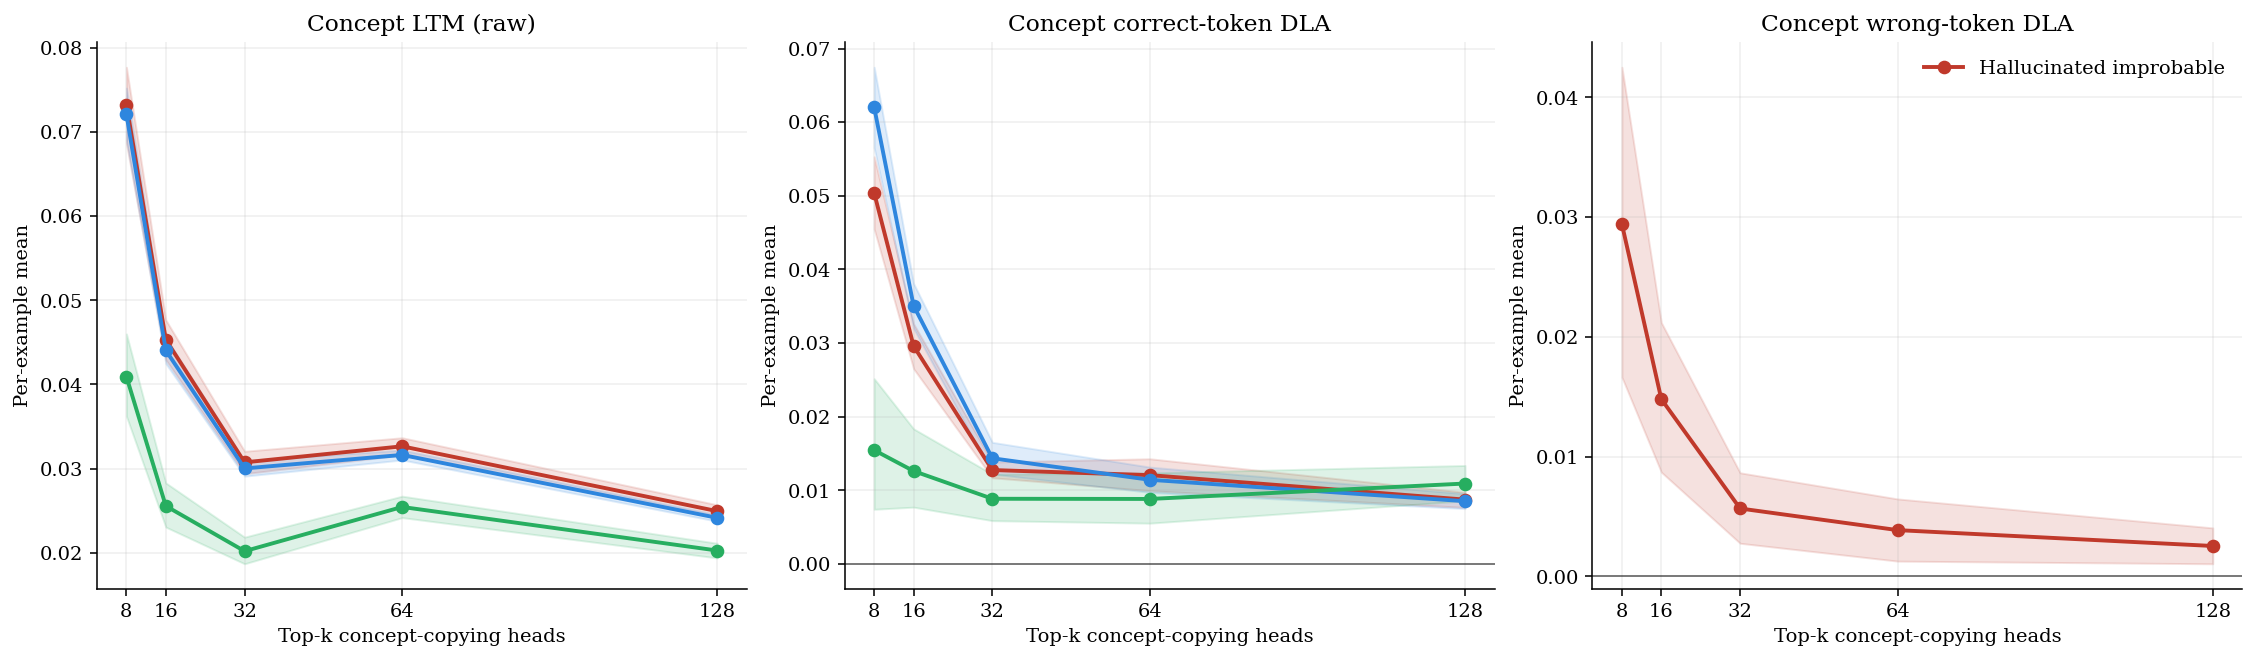

In [4]:
fig, axes, sweep = h1.plot_concept_k_sweep(CACHE, ks=(8, 16, 32, 64, 128))
display(sweep.round(6))

(<Figure size 1680x672 with 2 Axes>,
 array([<Axes: title={'center': 'Top-32 concept-head LTM'}, ylabel='Per-example mean'>,
        <Axes: title={'center': 'Top-32 concept-head correct-token DLA'}, ylabel='Per-example mean'>],
       dtype=object))

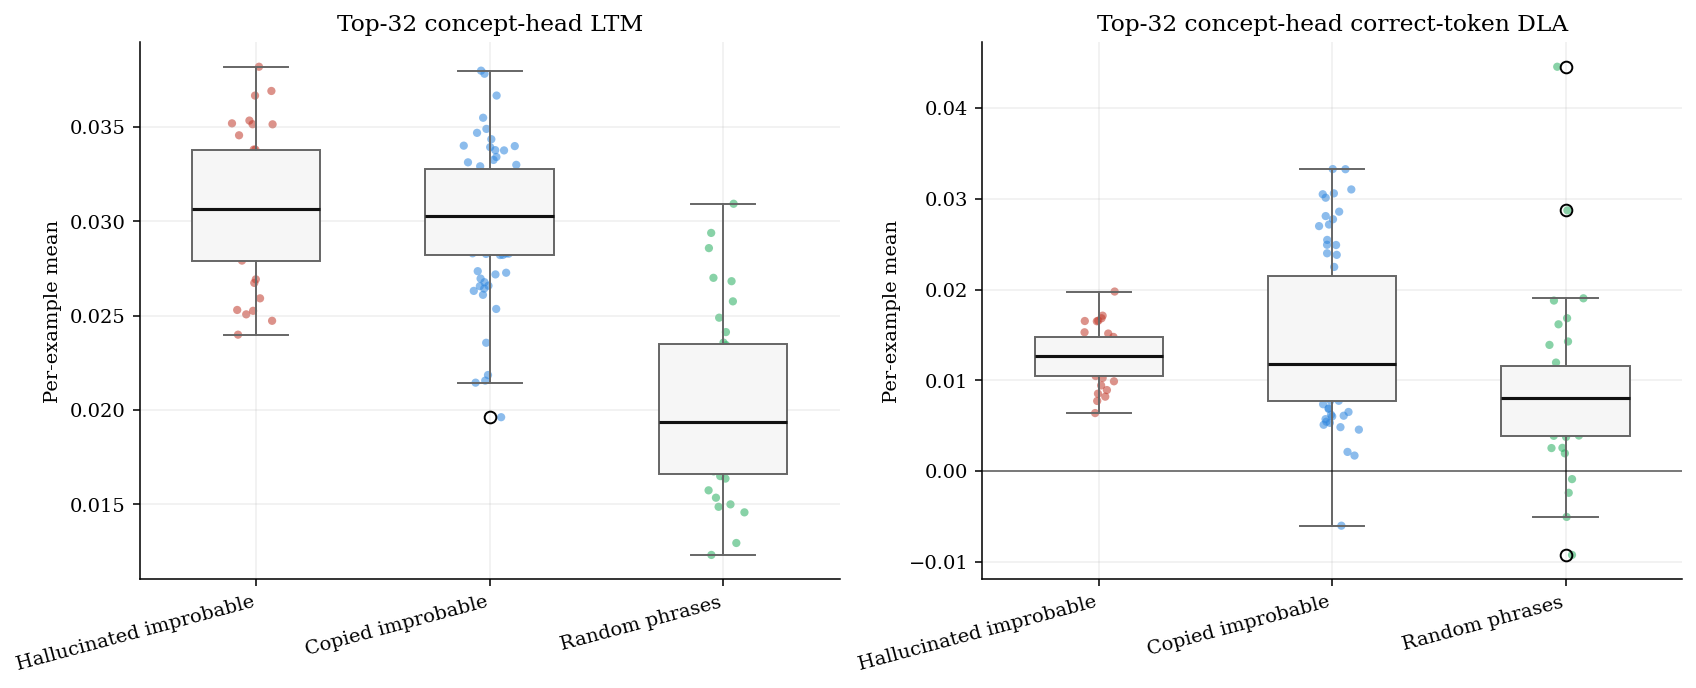

In [5]:
h1.plot_concept_distribution_panels(CACHE, DEFAULT_TOP_K)

(<Figure size 1540x630 with 2 Axes>,
 array([<Axes: title={'center': 'Hallucinated examples only, top-32 concept heads'}, xlabel='Correct-token DLA', ylabel='Predicted wrong-token DLA'>,
        <Axes: title={'center': 'Positive values favor the correct token'}, xlabel='Correct-token DLA minus wrong-token DLA', ylabel='Number of hallucinated examples'>],
       dtype=object))

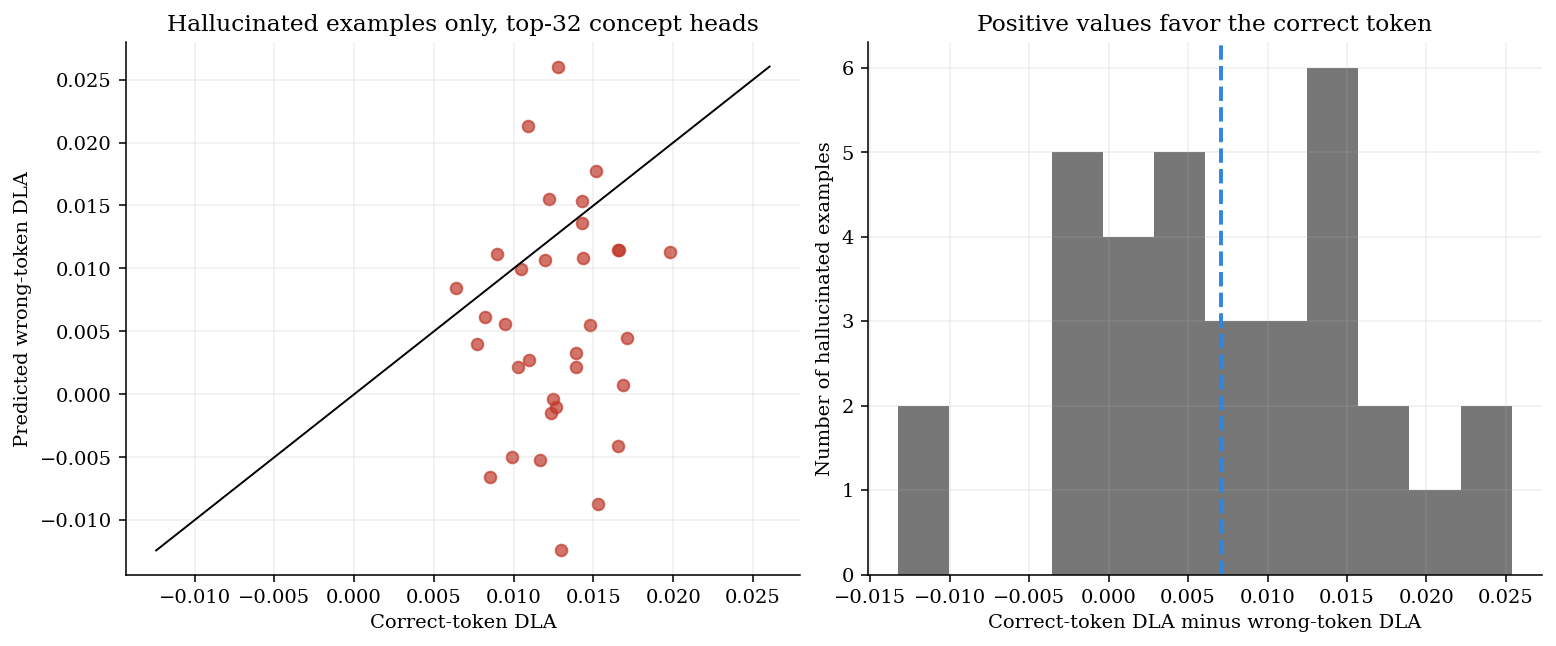

In [6]:
h1.plot_concept_hallucinated_dla_pair(CACHE, DEFAULT_TOP_K)

(<Figure size 1680x784 with 4 Axes>,
 array([<Axes: title={'center': 'Top-16 concept heads: LTM'}>,
        <Axes: title={'center': 'Top-16 concept heads: DLA'}>],
       dtype=object))

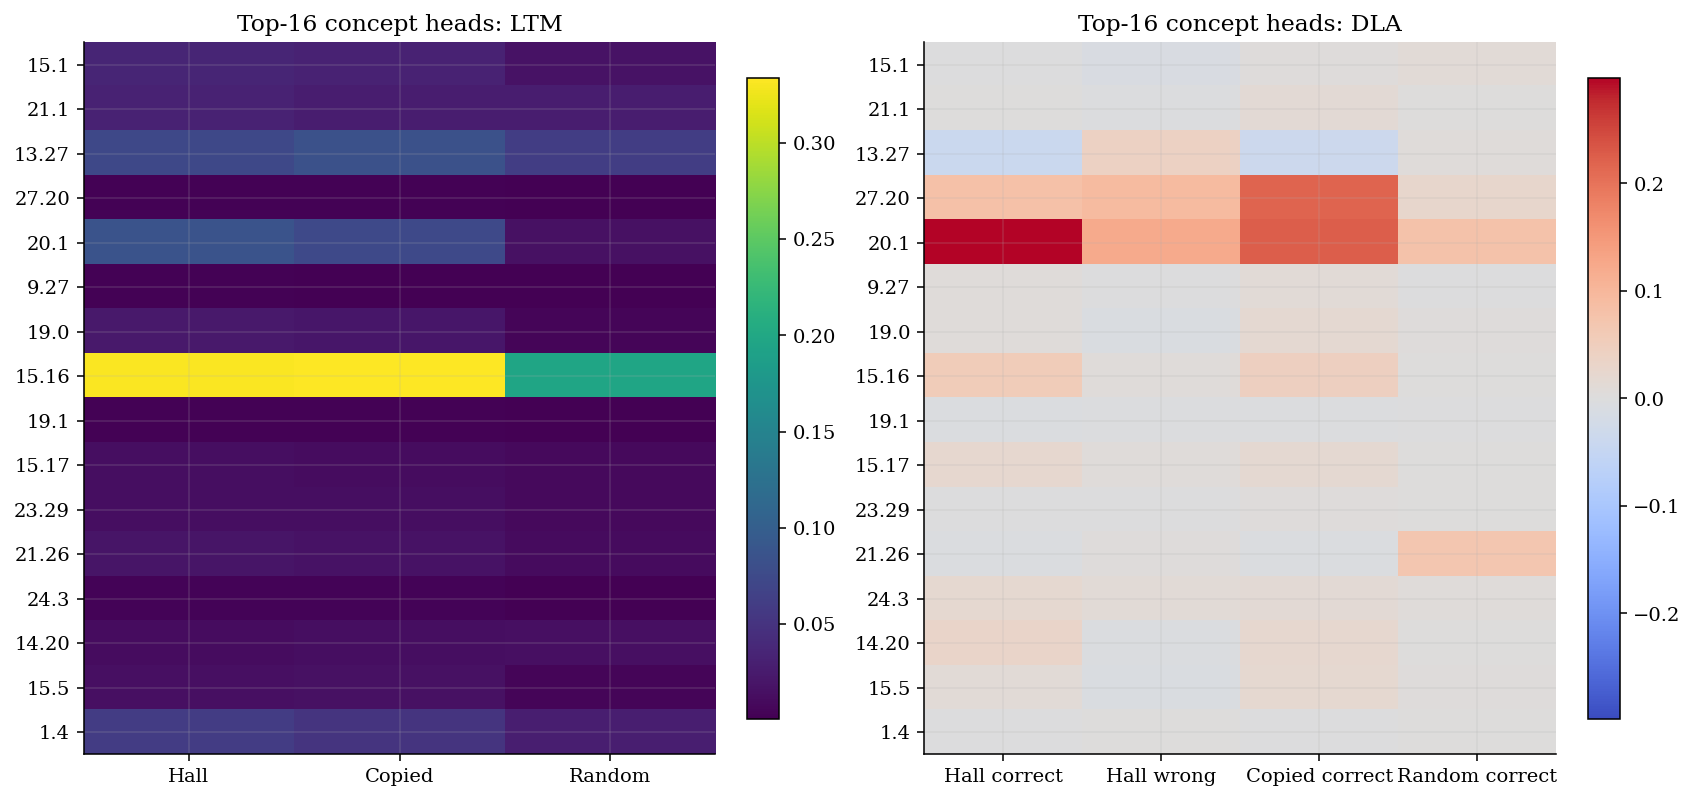

In [7]:
h1.plot_concept_head_heatmap(CACHE, top_k=16)

WindowsPath('D:/uni/courses/S2026/CS_7180/Project/improbable-bigram-causality/dual-route-induction/scripts/concept_head_figures')

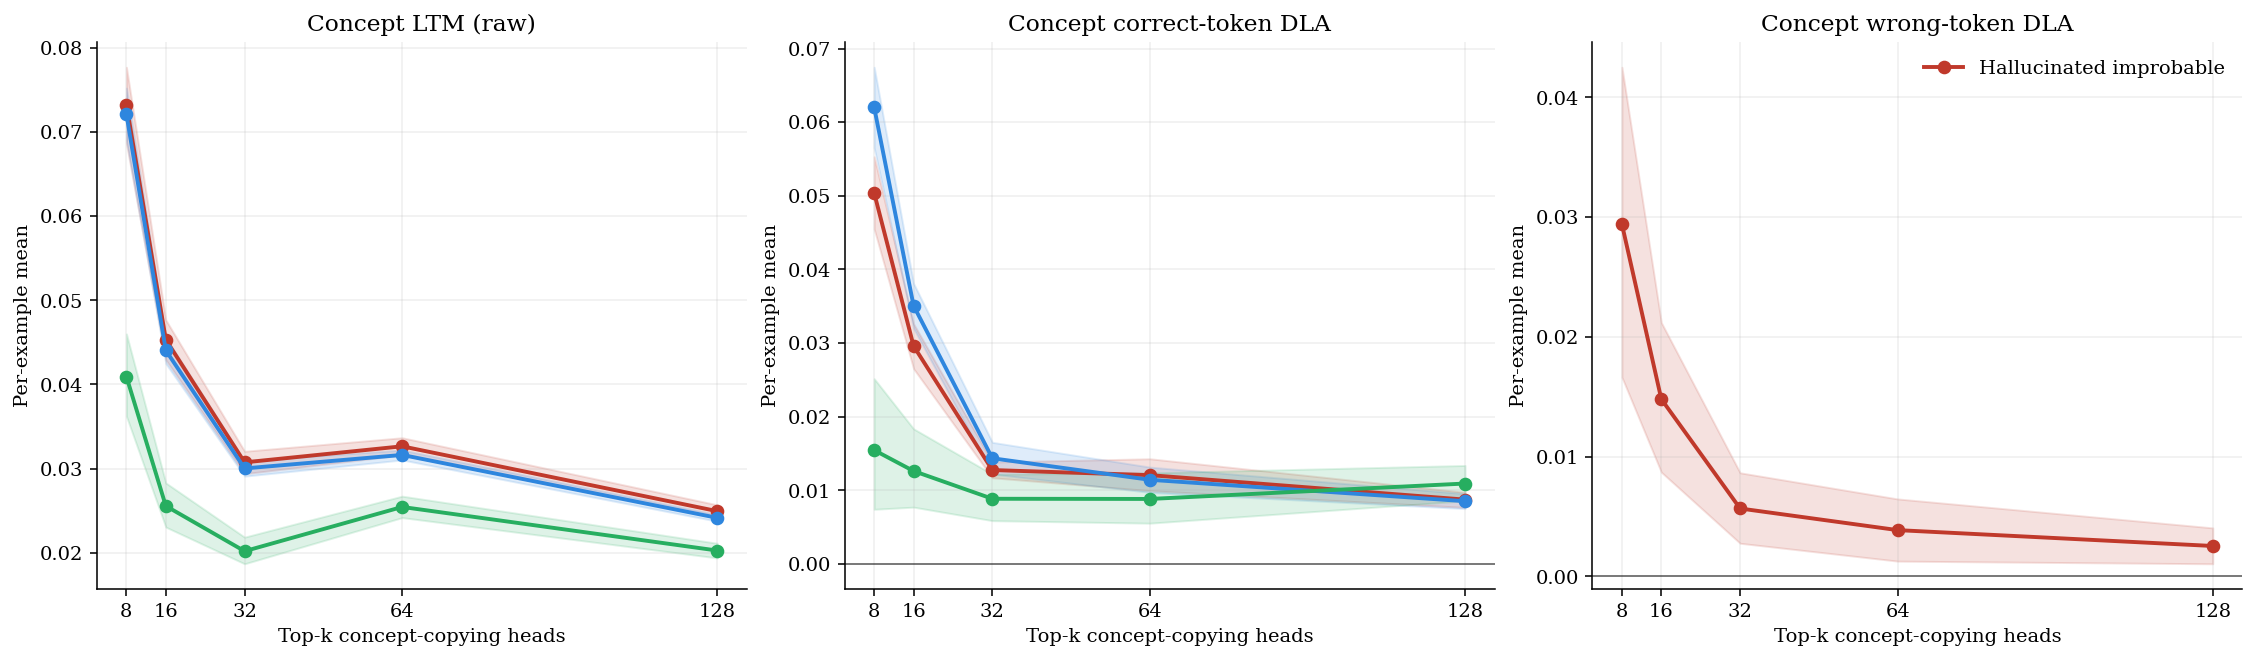

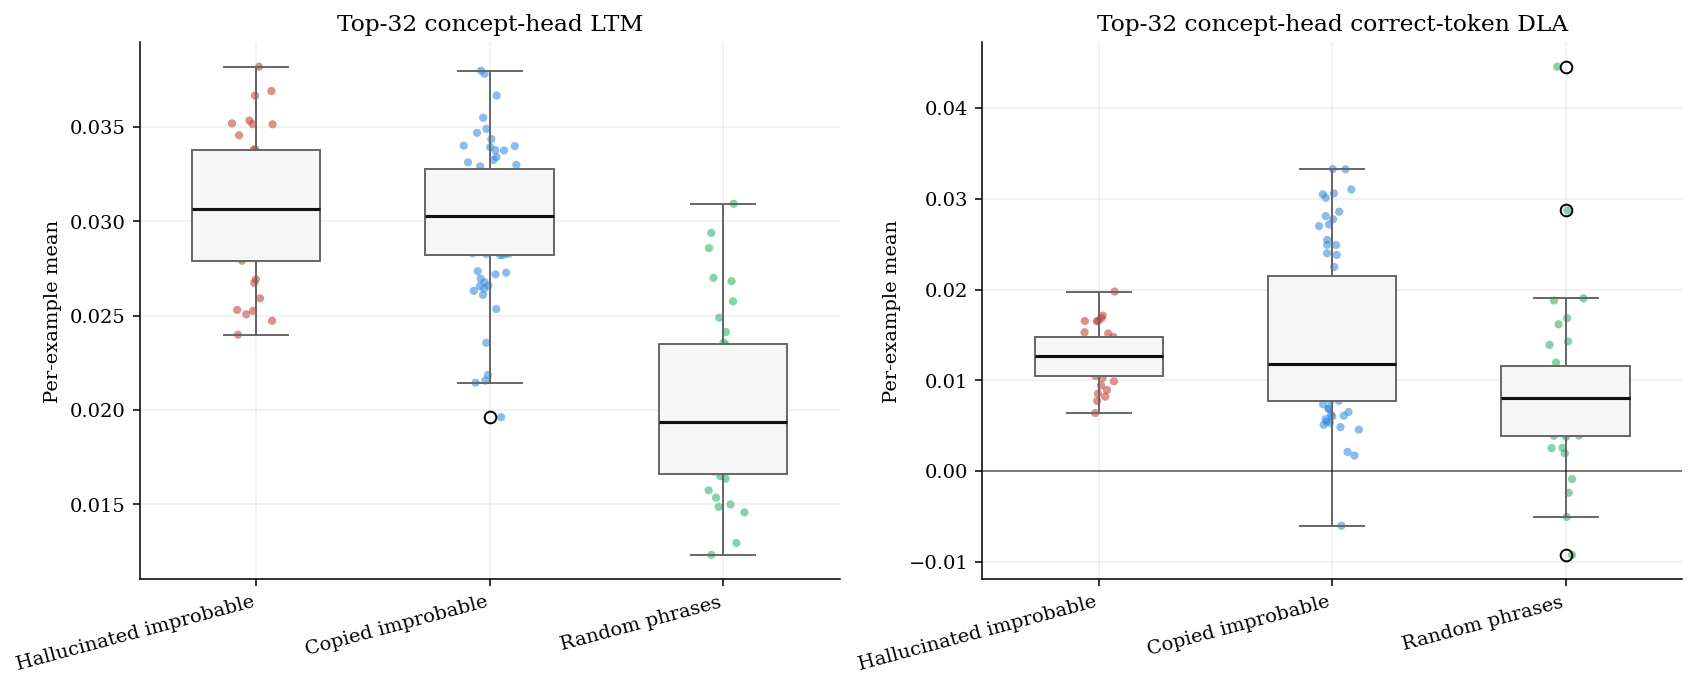

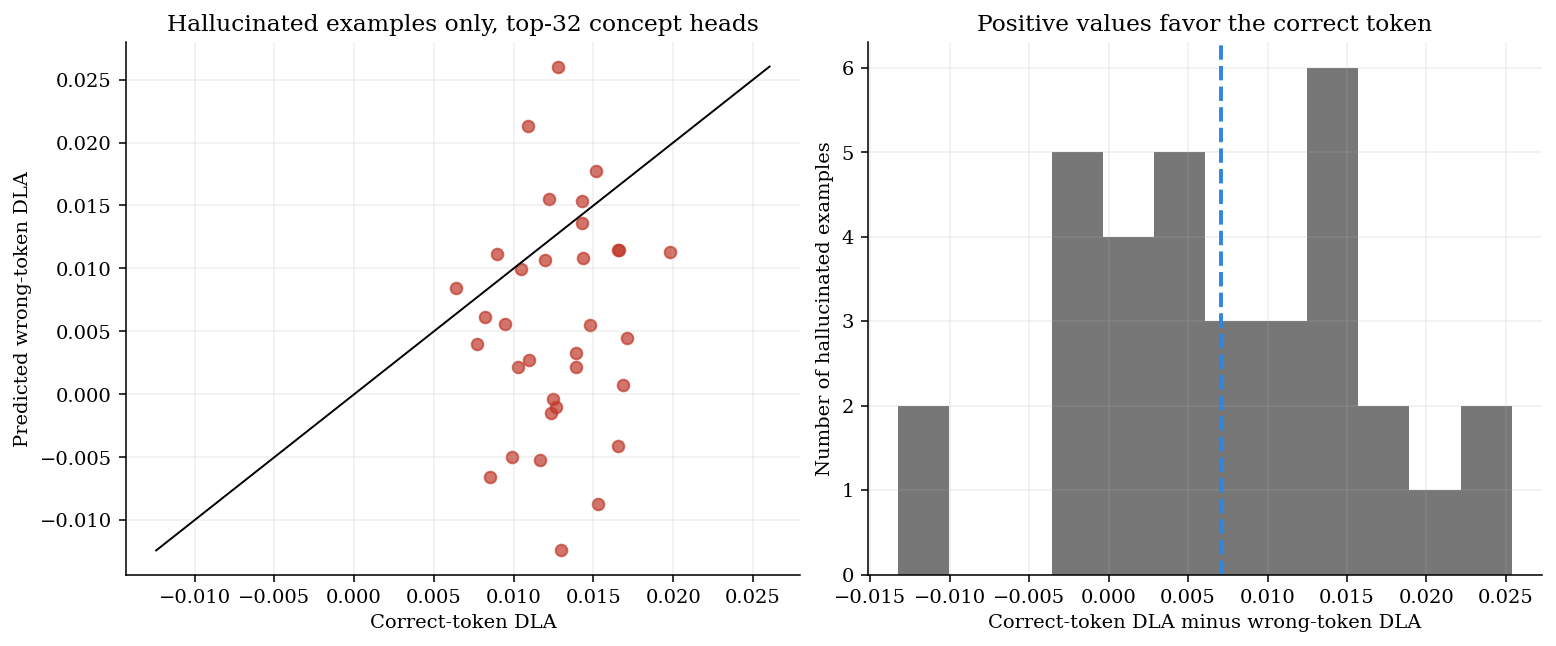

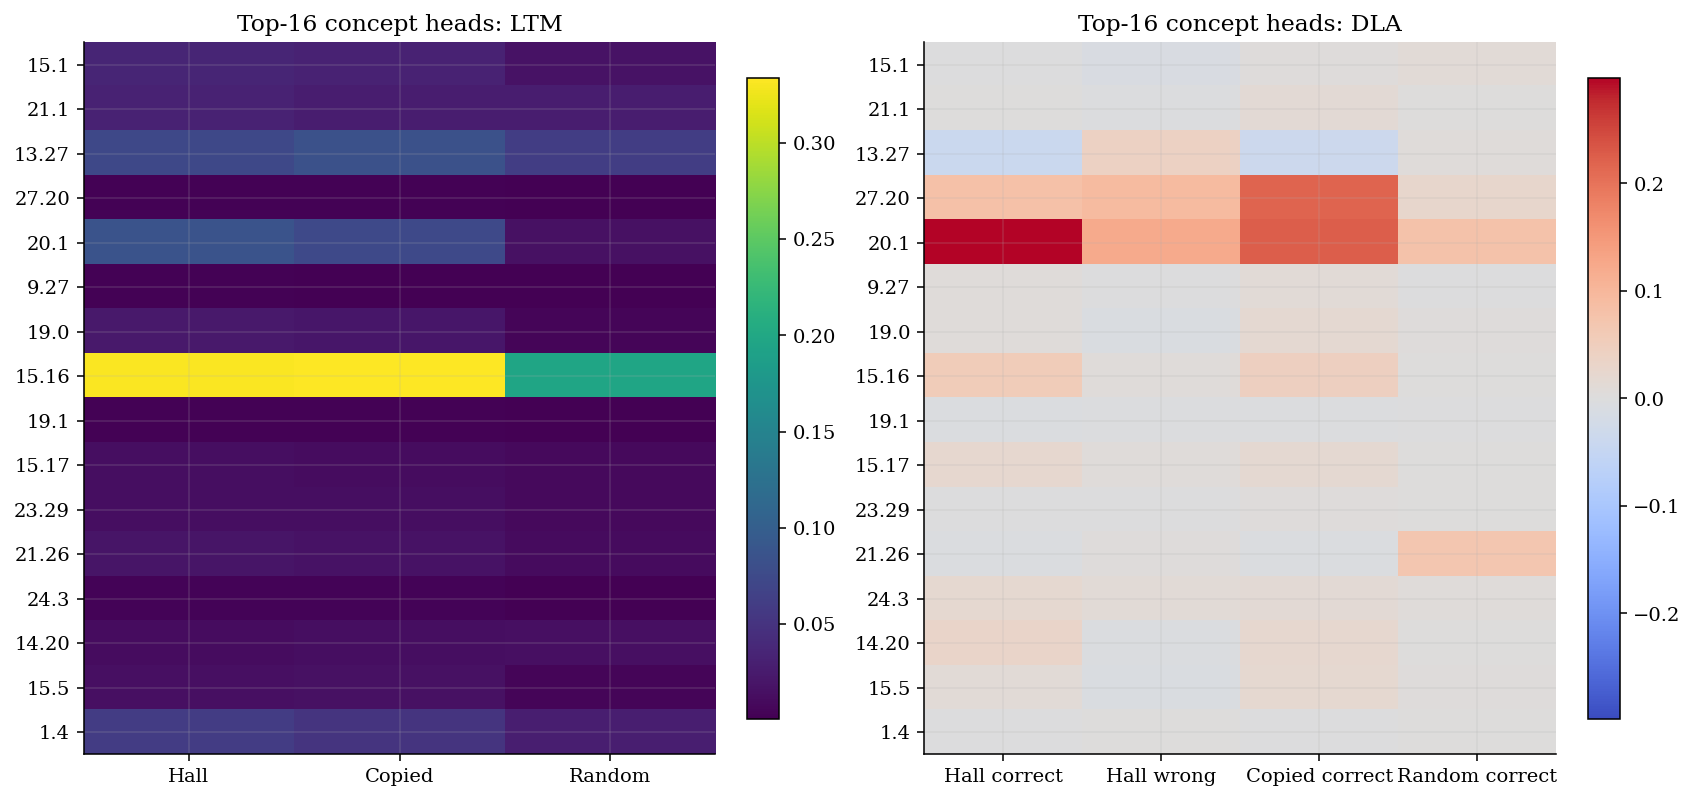

In [8]:
SAVE_DIR = ROOT / "scripts" / "concept_head_figures"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

_ = h1.plot_concept_k_sweep(
    CACHE, ks=(8, 16, 32, 64, 128), save_path=SAVE_DIR / "concept_k_sweep.png"
)
_ = h1.plot_concept_distribution_panels(
    CACHE, DEFAULT_TOP_K, save_path=SAVE_DIR / "concept_distributions.png"
)
_ = h1.plot_concept_hallucinated_dla_pair(
    CACHE, DEFAULT_TOP_K, save_path=SAVE_DIR / "concept_hallucinated_dla_pair.png"
)
_ = h1.plot_concept_head_heatmap(
    CACHE, top_k=16, save_path=SAVE_DIR / "concept_top_heads.png"
)
SAVE_DIR